In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Force displacement

In [ ]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('TensileTest_Group2.csv')

# Create a new DataFrame to store stress and strain data
stress_strain_df = pd.DataFrame()


# Define the runs and their corresponding labels
runs = {
    'Run #5': 'o-annealing',
    'Run #6': 'natural ageing',
    'Run #7': 'artificial ageing 1 hour',
    'Run #8': 'artificial ageing 24 hrs',
    'Run #9': 'Aluminium without treatment'
}

In [ ]:
plt.figure(figsize=(10, 6))

# Process and plot each run
for run_num, label in runs.items():
    displacement_col = f'Displ (mm) {run_num}'
    force_col = f'Tensile Force (N) {run_num}'

    # plot a graph of force vs displacement
    plt.plot(df[displacement_col], df[force_col], label=label)  

# Set title, labels, and legend
plt.title('Force vs Displacement for Different Aluminium Treatments')
plt.xlabel('Displacement (mm)')
plt.ylabel('Force (N)')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()

print("Force-Displacement graph has been generated successfully as 'Stress_Strain_Graph.png'.")

In [ ]:
# Define the dimensions of the sample
diameter_mm = 3.4
length_mm = 36.0

# Calculate the cross-sectional area in mm^2
radius_mm = diameter_mm / 2
area_mm2 = np.pi * (radius_mm)**2


plt.figure(figsize=(10, 6))

# Process and plot each run
for run_num, label in runs.items():
    displacement_col = f'Displ (mm) {run_num}'
    force_col = f'Tensile Force (N) {run_num}'

    # Calculate Stress (MPa = N/mm^2)
    stress_col = f'Stress (MPa) {run_num}'
    df[stress_col] = df[force_col] / area_mm2

    # Calculate Strain (mm/mm)
    strain_col = f'Strain (mm/mm) {run_num}'
    df[strain_col] = df[displacement_col] / length_mm

    # Store the calculated stress and strain data in the new DataFrame
    stress_strain_df[strain_col] = df[strain_col]
    stress_strain_df[stress_col] = df[stress_col] 
        
    # Plot the Stress-Strain curve
    plt.plot(stress_strain_df[strain_col], stress_strain_df[stress_col], label=label)

# Set title, labels, and legend
plt.title('Stress-Strain Graph for Different Aluminium Treatments')
plt.xlabel('Strain (mm/mm)')
plt.ylabel('Stress (MPa)')
# put legend at the top left corner
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()

# Save the stress_strain_df to a CSV file
stress_strain_df.to_csv('Stress_Strain_Data.csv', index=False)

print("Stress-Strain graph has been generated successfully as 'Stress_Strain_Graph.png'.")
print("The calculated stress and strain data have been saved to 'Stress_Strain_Data.csv'.")

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
#list of colors for each plot
colors = ['b', 'g', 'r', 'c', 'm', 'y']
offset_data = {
    'Run #5': 0.75,
    'Run #6': 0.67,
    'Run #7': 0.65,
    'Run #8': 0.75,
    'Run #9': 0.67
}

properties = {
    'Treatment': [],
    'Yield Strength (MPa)': [],
    'UTS (MPa)': [],
    'Max Elongation (%)': [],
    # 'Youngs Modulus (GPa)': []
}



for idx, (run_num, label) in enumerate(runs.items()):
    strain_col = f'Strain (mm/mm) {run_num}'
    stress_col = f'Stress (MPa) {run_num}'
    ax = axes[idx]
    ax.plot(stress_strain_df[strain_col], stress_strain_df[stress_col], label=label, color=colors[idx])

    # find the yield strength for each run and plot a horizontal line at that value
    yield_strength = stress_strain_df[stress_col].max() * offset_data[run_num]  # Example: 20% of max stress as yield strength
    ax.axhline(y=yield_strength,color=colors[idx] ,linestyle='--', label=f'Yield Strength {label}: {yield_strength:.2f} MPa')

    # Calculate UTS
    uts = stress_strain_df[stress_col].max()

    # Calculate Max Elongation
    max_elongation = stress_strain_df[strain_col].max() * 100  # convert to percentage

    # Calculate Young's Modulus (slope of the initial linear portion of the curve)
    # linear_region = stress_strain_df[stress_strain_df[strain_col] <= 0.002]  # assuming linear region is up to 0.2% strain
    # youngs_modulus = np.polyfit(linear_region[strain_col], linear_region[stress_col], 1)[0] / 1000  # convert to GPa
    
    # Append properties to the dictionary
    properties['Treatment'].append(label)
    properties['Yield Strength (MPa)'].append(yield_strength)
    properties['UTS (MPa)'].append(uts)
    properties['Max Elongation (%)'].append(max_elongation)
    # properties['Youngs Modulus (GPa)'].append(youngs_modulus)

    ax.set_title(label)
    ax.set_xlabel('Strain (mm/mm)')
    ax.set_ylabel('Stress (MPa)')
    ax.grid(True)
    ax.legend()

# Hide the last subplot if not used
if len(runs) < len(axes):
    for j in range(len(runs), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Create a DataFrame for a clean output
results_df = pd.DataFrame(properties)

# Print the results
print(results_df.to_string(index=False))

In [30]:
# Define sample dimensions
diameter_mm = 3.3
length_mm = 36.0
radius_mm = diameter_mm / 2
area_mm2 = np.pi * (radius_mm)**2


# Define runs and their corresponding labels
runs_data = {
    'Run #5': 'o-annealing',
    'Run #6': 'natural ageing',
    'Run #7': 'artificial ageing 1 hour',
    'Run #8': 'artificial ageing 24 hrs',
    'Run #9': 'Aluminium without treatment'
}

# Create a dictionary to store the calculated properties
properties = {
    'Treatment': [],
    'Yield Strength (MPa)': [],
    'UTS (MPa)': [],
    'Max Elongation (%)': [],
    'Youngs Modulus (GPa)': []
}

# Iterate through each run
for run_num, label in runs_data.items():
    force_col = f'Tensile Force (N) {run_num}'
    displacement_col = f'Displ (mm) {run_num}'

    # Filter out negative force and displacement values
    filtered_df = df[(df[force_col] > 100) & (df[displacement_col] >= 0)].copy()

    # Calculate stress and strain
    stress = filtered_df[force_col] / area_mm2
    strain = filtered_df[displacement_col] / length_mm

    # 1. Calculate Ultimate Tensile Strength (UTS)
    uts = stress.max()

    # 2. Calculate Maximum Elongation (ε)
    max_elongation = strain.max() * 100

    # 3. Calculate Young's Modulus (E)
    # Find the linear elastic region (e.g., first 0.5% strain)
    elastic_region_mask = strain < 0.014
    elastic_strain = strain[elastic_region_mask]
    elastic_stress = stress[elastic_region_mask]
    
    # Use a linear fit to find the slope (Young's Modulus)
    if len(elastic_strain) > 1:
        E, _ = np.polyfit(elastic_strain, elastic_stress, 1)
        E_gpa = E / 1000  # Convert MPa to GPa
    else:
        E_gpa = np.nan
        
    # 4. Calculate Yield Strength (σy) using the 0.2% offset method
    offset_strain = 1
    yield_strength = np.nan
    
    # Create the offset line using the calculated Young's Modulus
    if not np.isnan(E):
        offset_stress = E * (strain - offset_strain)

        # Find the first point where the experimental stress-strain curve intersects the offset line
        # This requires finding the first index where the experimental stress is greater than the offset stress
        for i in range(len(stress)):
            if stress.iloc[i] >= offset_stress.iloc[i]:
                yield_strength = stress.iloc[i]
                break
    
    # Store the results
    properties['Treatment'].append(label)
    properties['Yield Strength (MPa)'].append(yield_strength)
    properties['UTS (MPa)'].append(uts)
    properties['Max Elongation (%)'].append(max_elongation)
    properties['Youngs Modulus (GPa)'].append(E_gpa)

# Create a DataFrame for a clean output
results_df = pd.DataFrame(properties)

# Print the results
print(results_df.to_string(index=False))

                  Treatment  Yield Strength (MPa)  UTS (MPa)  Max Elongation (%)  Youngs Modulus (GPa)
                o-annealing             28.904525 162.393578           13.444444              4.874163
             natural ageing             68.841455 555.038907           16.472222                   NaN
   artificial ageing 1 hour             27.018634 511.555847           18.111111                   NaN
   artificial ageing 24 hrs             32.310353 442.544861            9.611111             29.411080
Aluminium without treatment             15.028670 480.681250           20.000000             25.212500


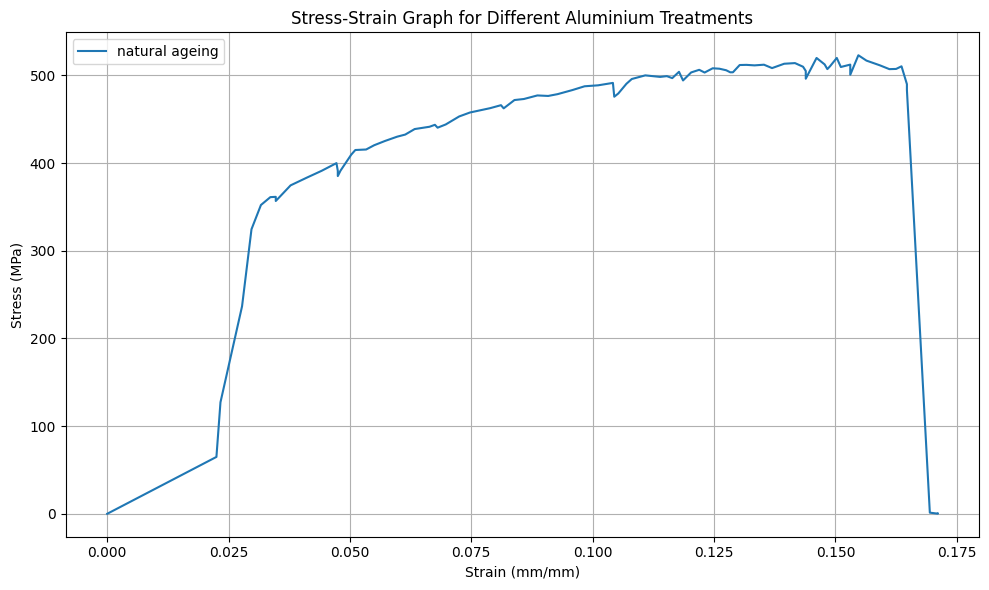

In [34]:
# Define sample dimensions
diameter_mm = 3.4
length_mm = 36.0
radius_mm = diameter_mm / 2
area_mm2 = np.pi * (radius_mm)**2

runs_data = {
    # 'Run #5': 'o-annealing',
    'Run #6': 'natural ageing',
    # 'Run #7': 'artificial ageing 1 hour',
    # 'Run #8': 'artificial ageing 24 hrs',
    # 'Run #9': 'Aluminium without treatment'
}

# Create a new DataFrame to store stress and strain data
stress_strain_df = pd.DataFrame()

plt.figure(figsize=(10, 6))

# Process and plot each run
for run_num, label in runs_data.items():
    displacement_col = f'Displ (mm) {run_num}'
    force_col = f'Tensile Force (N) {run_num}'

    # Calculate Stress (MPa = N/mm^2)
    stress_col = f'Stress (MPa) {run_num}'
    df[stress_col] = df[force_col] / area_mm2

    # Calculate Strain (mm/mm)
    strain_col = f'Strain (mm/mm) {run_num}'
    df[strain_col] = df[displacement_col] / length_mm
    
    # Store the calculated stress and strain data in the new DataFrame and offset the strain data to account for initial errors
    stress_strain_df[strain_col] = df[strain_col]
    stress_strain_df[stress_col] = df[stress_col] 
        

    # Plot the Stress-Strain curve
    plt.plot(stress_strain_df[strain_col], stress_strain_df[stress_col], label=label)

# Set title, labels, and legend
plt.title('Stress-Strain Graph for Different Aluminium Treatments')
plt.xlabel('Strain (mm/mm)')
plt.ylabel('Stress (MPa)')
# put legend at the top left corner
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()